### Setup

In [1]:
!./venv/bin/pip3 install kaggle pandas matplotlib seaborn numpy scikit-learn reparo imperio

  Using cached kaggle-2.0.0-py3-none-any.whl.metadata (15 kB)
  Using cached pandas-3.0.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached numpy-2.4.2-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.6 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached reparo-0.0.6-py3-none-any.whl.metadata (3.5 kB)
  Using cached bleach-6.3.0-py3-none-any.whl.metadata (31 kB)
  Using cached kagglesdk-0.1.16-py3-none-any.whl.metadata (13 kB)
  Using cached protobuf-7.34.0-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached python_slugify-8.0.4-py2.py3-none-any.whl.metadata (8.5 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)

#### Imports

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM, SVC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imperio import FrequencyImputationTransformer, BoxCoxTransformer, ZCATransformer
from reparo import CDI

Options

In [3]:
pd.set_option('display.expand_frame_repr', False)

### Data Collection

I wanted to once again try my skills on the Titanic dataset to see how much I can increase the test accuracy and f1-score

In [77]:
!kaggle competitions download -c titanic

100%|███████████████████████████████████████| 34.1k/34.1k [00:00<00:00, 592kB/s]



In [78]:
!unzip titanic.zip

Archive:  titanic.zip
  inflating: gender_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [6]:
train_df = pd.read_csv("train.csv")
print(train_df.describe())
train_df.head(5)

       PassengerId    Survived      Pclass         Age       SibSp       Parch        Fare
count   891.000000  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean    446.000000    0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std     257.353842    0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min       1.000000    0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%     223.500000    0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%     446.000000    0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%     668.500000    1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max     891.000000    1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### EDA

#### Columns with Missing Values

We have two columns with missing values: `Age` and `Cabin` 

In [41]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

I am interested in a passanger's conditional probability of surviving given that some data about them is missing. Missing data is also data

P(Surviving | Cabin is missing) = 30%

In [40]:
contingency_table = pd.crosstab(
    train_df['Survived'], 
    train_df.isnull()["Cabin"].rename("Cabin missing"), 
    normalize="columns"
)

contingency_table

Cabin missing,False,True
Survived,,
0,0.333333,0.700146
1,0.666667,0.299854


In [163]:
train_df["Survived"].corr(train_df.isnull()["Cabin"])

np.float64(-0.3169115231122965)

P(Surviving | Age is missing) = 30%

In [35]:
pd.crosstab(
    train_df['Survived'], 
    train_df.isnull()["Age"].rename("Age missing"), 
    normalize="columns"
)

Age missing,False,True
Survived,,
0,0.593838,0.706215
1,0.406162,0.293785


In [162]:
train_df["Survived"].corr(train_df.isnull()["Age"])

np.float64(-0.09219652324217194)

Combine both observations to reduce the number of features. We can see that the values are approximately the same

In [39]:
pd.crosstab(
    train_df['Survived'], 
    np.logical_or(train_df.isnull()["Age"], train_df.isnull()["Cabin"]).rename("Age or Cabin missing"), 
    normalize="columns"
)

Age or Cabin missing,False,True
Survived,,
0,0.324324,0.692635
1,0.675676,0.307365


About 80% of passangers has some missing data

In [43]:
np.logical_or(train_df.isnull()["Age"], train_df.isnull()["Cabin"]).value_counts() / len(train_df) 

True     0.792368
False    0.207632
Name: count, dtype: float64

So far it is top 3 in terms of correlation with target column, so we can keep it

In [46]:
train_df["Survived"].corr(np.logical_or(train_df.isnull()["Age"], train_df.isnull()["Cabin"]))

np.float64(-0.30718696207343293)

### Plotting

#### Categorical Count Plots

/Users/maxim/Documents/work/sigmoid_hw/15_Feature_Engineering/venv/lib/python3.13/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


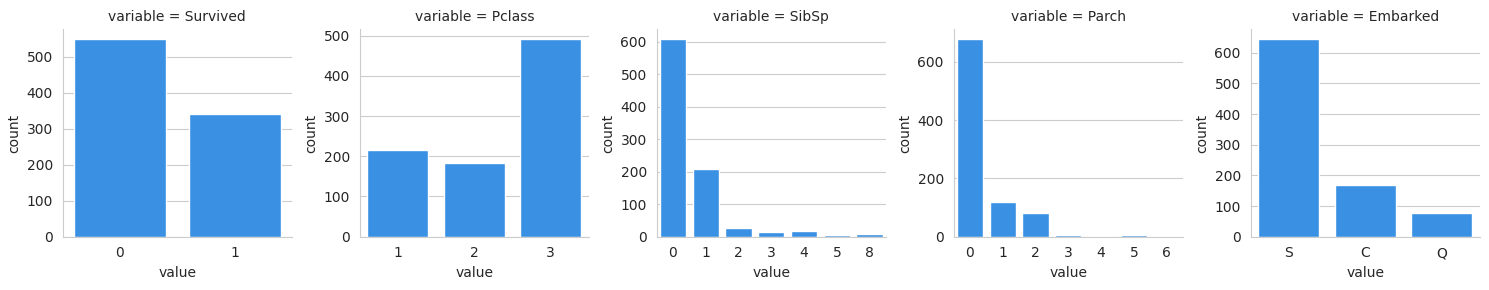

In [51]:
count_cols = ["Survived", "Pclass", "SibSp", "Parch", "Embarked"]
with sns.axes_style('whitegrid'):
  nd = pd.melt(train_df, value_vars=count_cols)
  n1 = sns.FacetGrid(nd, col='variable', col_wrap=5, sharex=False, sharey=False)
  n1 = n1.map(sns.countplot, 'value', color='#1e90ff')


#### Continuous Values

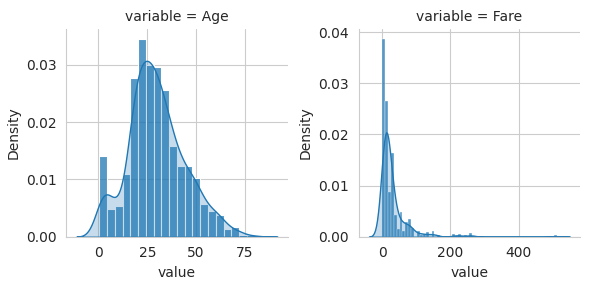

In [45]:
kde_cols = ["Age", "Fare"]

with sns.axes_style('whitegrid'):
  nd = pd.melt(train_df, value_vars=kde_cols)
  n1 = sns.FacetGrid(nd, col='variable', col_wrap=2, sharex=False, sharey=False)

  n1.map(
      sns.histplot,
      'value',
      stat='density',
  )

  n1.map(
      sns.kdeplot,
      'value',
      fill=True
  )

#### Box Plots

There were many Fare outliers, since some people paid a lot more for luxurious tickets. From removed cell, about 68% of people who paid fare > 50 have survived

/Users/maxim/Documents/work/sigmoid_hw/15_Feature_Engineering/venv/lib/python3.13/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


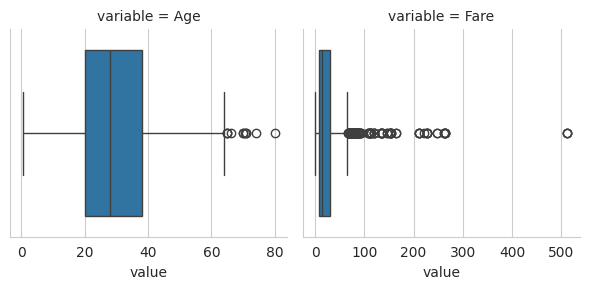

In [52]:
kde_cols = ["Age", "Fare"]

with sns.axes_style('whitegrid'):
  nd = pd.melt(train_df, value_vars=kde_cols)
  n1 = sns.FacetGrid(nd, col='variable', col_wrap=2, sharex=False, sharey=False)

  n1.map(
      sns.boxplot,
      'value',
  )

#### Age density Distribution by Survival

Younger folks (not kids) were much more likely to not survive

Text(0.5, 1.0, 'Age density Distribution by Survival')

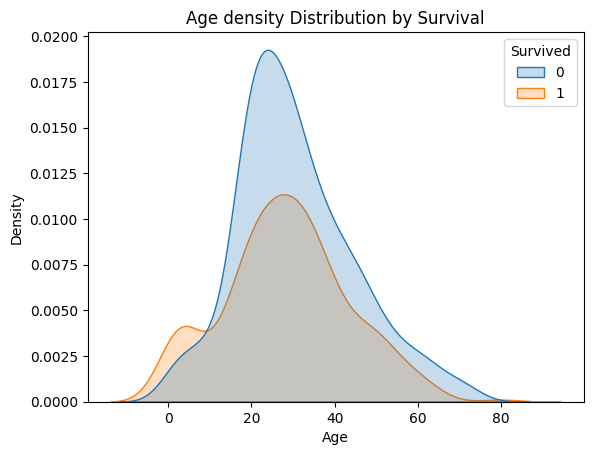

In [75]:
sns.kdeplot(data=train_df, x='Age', hue='Survived', fill=True)
plt.title("Age density Distribution by Survival")

### Feature Engineering

#### Extracting Title from Name

In [47]:
title_list=['Mrs', 'Mr', 'Master', 'Miss', 'Major', 'Rev',
                    'Dr', 'Ms', 'Mlle','Col', 'Capt', 'Mme', 'Countess',
                    'Don', 'Jonkheer']

pattern = f"({'|'.join(title_list)})"

train_df["Title"] = train_df["Name"].str.extract(pattern, expand=False)

In [48]:
def replace_titles(x):
    title=x['Title']
    if title in ['Don', 'Major', 'Capt', 'Jonkheer', 'Rev', 'Col']:
        return 'Mr'
    elif title in ['Countess', 'Mme']:
        return 'Mrs'
    elif title in ['Mlle', 'Ms']:
        return 'Miss'
    elif title =='Dr':
        if x['Sex']=='Male':
            return 'Mr'
        else:
            return 'Mrs'
    else:
        return title
train_df['Title'] = train_df.apply(replace_titles, axis=1)

Different frequencies means that we can use frequency imputation transformer to encode this column

In [90]:
train_df["Title"].value_counts()

Title
Mr        532
Miss      183
Mrs       136
Master     40
Name: count, dtype: int64

In [56]:
train_df["Title"].value_counts() / len(train_df)

Title
Mr        0.597082
Miss      0.205387
Mrs       0.152637
Master    0.044893
Name: count, dtype: float64

#### Extracting Deck from Cabin

In [69]:
cabin_list = ['A', 'B', 'C', 'D', 'E', 'F', 'T', 'G', 'Unknown']
pattern = f"({'|'.join(cabin_list)})"
train_df['Deck'] = train_df['Cabin'].str.extract(pattern, expand=True)

In [110]:
train_df["Deck"].value_counts() / len(train_df)

Deck
C    0.066218
B    0.052750
D    0.037037
E    0.035915
A    0.016835
F    0.014590
G    0.004489
T    0.001122
Name: count, dtype: float64

In [89]:
train_df["Embarked"].value_counts() / len(train_df)

Embarked
S    0.722783
C    0.188552
Q    0.086420
Name: count, dtype: float64

In [161]:
train_df["Survived"].corr((train_df["SibSp"] + train_df["Parch"]) == 1)

np.float64(0.16315683404651538)

<Axes: ylabel='Density'>

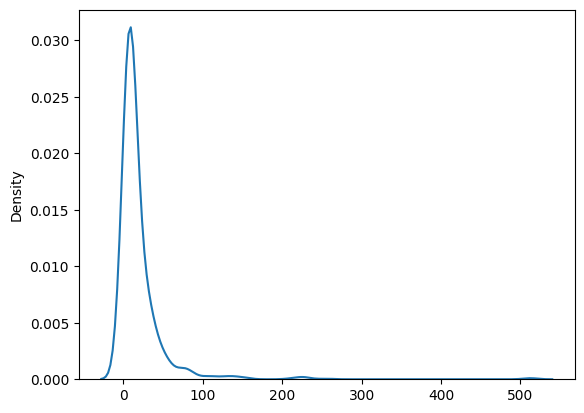

In [179]:
sns.kdeplot(data=train_df["Fare"] / (train_df["SibSp"] + train_df["Parch"] + 1))

In [95]:
train_df["Survived"].corr(train_df["Fare"] / (train_df["SibSp"] + train_df["Parch"] + 1))

np.float64(0.22159990528456933)

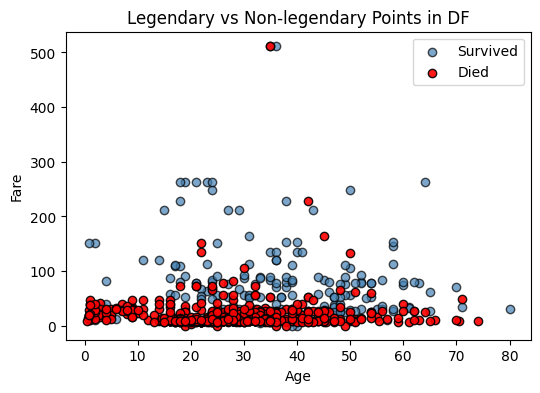

In [109]:
legendary_mask = train_df["Cabin"].isnull()

plt.figure(figsize=(6, 4))
plt.scatter(
    train_df.loc[~legendary_mask, "Age"],
    train_df.loc[~legendary_mask, "Fare"],
    c="steelblue", label="Survived", alpha=0.7, edgecolors="k"
)
plt.scatter(
    train_df.loc[legendary_mask, "Age"],
    train_df.loc[legendary_mask, "Fare"],
    c="red", label="Died", alpha=0.9, edgecolors="k"
)
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Legendary vs Non-legendary Points in DF")
plt.legend()

remove id and other unused columns
aggregate categorical
convert categorical
scale categorical
removed unused categorical columns
impute data
create new features
scale the dataset
remove outliers

create pipeline with steps above 
try different classifiers to see which performs best
tune hyperparameters
cross-validate on test dataset

### Pipeline

#### Helper Functions

In [127]:
def remove_cols(df: pd.DataFrame):
    return df.drop(columns=["PassengerId", "Ticket"])

In [205]:
def replace_titles(x):
    title=x['Title']
    if title in ['Don', 'Major', 'Capt', 'Jonkheer', 'Rev', 'Col']:
        return 'Mr'
    elif title in ['Countess', 'Mme']:
        return 'Mrs'
    elif title in ['Mlle', 'Ms']:
        return 'Miss'
    elif title =='Dr':
        if x['Sex']=='Male':
            return 'Mr'
        else:
            return 'Mrs'
    else:
        return title

title_list=['Mrs', 'Mr', 'Master', 'Miss', 'Major', 'Rev',
                    'Dr', 'Ms', 'Mlle','Col', 'Capt', 'Mme', 'Countess',
                    'Don', 'Jonkheer']

def aggregate_categorical(df: pd.DataFrame):
    title_pattern = f"({'|'.join(title_list)})"

    df["Title"] = df["Name"].str.extract(title_pattern, expand=False)
    df["Title"] = df.apply(replace_titles, axis=1)
    
    cabin_list = ['A', 'B', 'C', 'D', 'E', 'F', 'T', 'G', 'Unknown']
    cabin_pattern = f"({'|'.join(cabin_list)})"
    df['Deck'] = df['Cabin'].str.extract(cabin_pattern, expand=True)
    df['Deck'] = df['Deck'].fillna('Unknown')
    df['Embarked'] = df['Embarked'].fillna('Unknown')
    df['Title'] = df['Title'].fillna('Unknown')

    df['Embarked'] = pd.Categorical(df['Embarked']).codes
    df['Title'] = pd.Categorical(df['Title']).codes
    df['Deck'] = pd.Categorical(df['Deck']).codes

    df["Cabin_missing"] = df.isnull()["Cabin"].astype(int)
    df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

    return df.drop(columns=["Name", "Cabin"])

In [287]:
def create_features(df: pd.DataFrame):
    # df["Age_missing"] = df.isnull()["Age"].astype(int)

    familyNum = df["SibSp"] + df["Parch"]
    # df["isSingle"] = (familyNum == 1).astype(int)
    df["FarePerFamily"] = df["Fare"] / (familyNum + 1)

    return df

#### Adapter Classes for Pipeline

In [292]:
class DataFrameFrequencyImputer(BaseEstimator, TransformerMixin):
    def __init__(self, columns, min_int_freq=5):
        self.columns = columns
        self.min_int_freq = min_int_freq

    def fit(self, X, y=None):
        missing_cols = set(self.columns) - set(X.columns)
        if missing_cols:
            raise ValueError(f"Columns not found: {sorted(missing_cols)}")

        self.columns_ = X.columns.tolist()
        index = X.columns.get_indexer(self.columns).tolist()
        self.imputer_ = FrequencyImputationTransformer(index=index, min_int_freq=self.min_int_freq)

        y_array = y.to_numpy() if hasattr(y, "to_numpy") else y
        self.imputer_.fit(X.to_numpy(), y_array)
        return self

    def transform(self, X):
        X_t = self.imputer_.transform(X.to_numpy())
        return pd.DataFrame(X_t, columns=self.columns_, index=X.index)


class DataFrameCDI(BaseEstimator, TransformerMixin):
    def __init__(self, **kwargs):
        self.kwargs = kwargs

    def fit(self, X, y=None):
        self.columns_ = X.columns.tolist()
        self.cdi_ = CDI(**self.kwargs)
        self.cdi_.fit(X.to_numpy())
        self.fitted_ = True
        return self

    def transform(self, X):
        X_t = self.cdi_.transform(X.to_numpy())
        return pd.DataFrame(X_t, columns=self.columns_, index=X.index)


class DataFrameSelectiveZCA(BaseEstimator, TransformerMixin):
    def __init__(self, columns, eps=10e-5):
        self.columns = columns
        self.eps = eps

    def fit(self, X, y=None):
        missing_cols = set(self.columns) - set(X.columns)
        if missing_cols:
            raise ValueError(f"Columns not found for ZCA: {sorted(missing_cols)}")

        self.zca_ = ZCATransformer(eps=self.eps)
        self.zca_.fit(X[self.columns].to_numpy(), y)
        self.fitted_ = True
        return self

    def transform(self, X):
        X_out = X.copy()
        X_out.loc[:, self.columns] = self.zca_.transform(X[self.columns].to_numpy())
        return X_out


class DataFrameBoxCox(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.boxcox_ = BoxCoxTransformer()

    def fit(self, X, y=None):
        arr = X.to_numpy() if hasattr(X, "to_numpy") else X
        self.boxcox_.fit(arr, y)
        self.fitted_ = True
        return self

    def transform(self, X):
        arr = X.to_numpy() if hasattr(X, "to_numpy") else X
        return self.boxcox_.transform(arr)


class OutlierExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=20, contamination='auto', add_flag=True):
        self.n_neighbors = n_neighbors
        self.contamination = contamination
        self.add_flag = add_flag

    def fit(self, X, y=None):
        self.input_is_dataframe_ = hasattr(X, 'columns') and hasattr(X, 'index')
        if self.input_is_dataframe_:
            self.columns_ = X.columns.tolist()
            X_values = X.to_numpy()
        else:
            self.columns_ = None
            X_values = X

        self.lof_ = LocalOutlierFactor(
            n_neighbors=self.n_neighbors,
            contamination=self.contamination,
            novelty=True
        )
        self.lof_.fit(X_values)
        self.fitted_ = True
        return self

    def transform(self, X):
        if self.input_is_dataframe_:
            X_values = X.to_numpy()
            outlier_flag = (self.lof_.predict(X_values) == -1).astype(int)
            X_out = X.copy()
            if self.add_flag:
                X_out['OutlierFlag'] = outlier_flag
            return X_out

        outlier_flag = (self.lof_.predict(X) == -1).astype(int)
        if self.add_flag:
            return np.column_stack([X, outlier_flag])
        return X

#### Creating the Pipeline

In [260]:
clean_train_df = pd.read_csv("train.csv")
X_train = clean_train_df.drop("Survived", axis=1)
y_train = clean_train_df["Survived"]

preview_df = create_features(aggregate_categorical(remove_cols(X_train.head(1).copy())))
scaled_cols = ["Fare", "FarePerFamily", "SibSp", "Parch"]
standard_cols = ["Age"]
passthrough_cols = [col for col in preview_df.columns if col not in scaled_cols + standard_cols]
final_columns = scaled_cols + standard_cols + passthrough_cols
zca_cols = ["Fare", "FarePerFamily"]

df_proc_pipeline = Pipeline([
    ('drop_cols', FunctionTransformer(remove_cols)),
    ('agg_cat', FunctionTransformer(aggregate_categorical)),
    ('target_embarked_title_deck', DataFrameFrequencyImputer(columns=["Embarked", "Title", "Deck"])),
    ('feature_eng', FunctionTransformer(create_features)),
    ('impute_deck_age', DataFrameCDI()),
    ('scaling', ColumnTransformer([
        ('right_skewed', DataFrameBoxCox(), scaled_cols),
        ('standard', StandardScaler(), standard_cols),
    ], remainder='passthrough')),
    ('to_dataframe', FunctionTransformer(
        lambda arr: pd.DataFrame(arr, columns=final_columns),
        validate=False
    )),
    ('zca', DataFrameSelectiveZCA(columns=zca_cols)),
    ('outlier', OutlierExtractor()),
])

X_train_transformed = df_proc_pipeline.fit_transform(X_train, y_train)
y_train_aligned = y_train.loc[X_train_transformed.index]
X_train_transformed.describe()

,Fare,FarePerFamily,SibSp,Parch,Age,Pclass,Sex,Embarked,Title,Deck,Cabin_missing,Age_missing,isSingle
count,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000,820.000000
mean,0.022681,0.015626,-1.190301,-1.381048,0.004405,2.274390,0.380488,0.571056,0.411189,0.595052,0.757317,0.180488,0.193902
std,0.025679,0.029744,1.209647,1.108220,1.012047,0.843898,0.485803,0.252805,0.215380,0.311206,0.428967,0.384828,0.395595
min,-0.002080,-0.070652,-2.000000,-2.000000,-2.245595,1.000000,0.000000,0.002245,0.044893,0.001122,0.000000,0.000000,0.000000
25%,0.003821,-0.000846,-2.000000,-2.000000,-0.589239,1.000000,0.000000,0.188552,0.205387,0.771044,1.000000,0.000000,0.000000
50%,0.009472,0.018555,-2.000000,-2.000000,0.024795,3.000000,0.000000,0.722783,0.597082,0.771044,1.000000,0.000000,0.000000
75%,0.036054,0.023244,0.000000,0.000000,0.485320,3.000000,1.000000,0.722783,0.597082,0.771044,1.000000,0.000000,0.000000
max,0.160619,0.224465,3.656854,2.898979,3.862505,3.000000,1.000000,0.722783,0.597082,0.771044,1.000000,1.000000,1.000000


#### VIF Analysis

As I have done some feature engineering, I want to check the Variance Inflation Factor (VIF) to see if I have correlated columns in my dataset

In [243]:
def print_vifs(vif_df: pd.DataFrame):
    vif_data = pd.DataFrame()
    vif_data["feature"] = vif_df.columns

    vif_data["VIF"] = [variance_inflation_factor(vif_df.values, i)
                            for i in range(len(vif_df.columns))]
    print(vif_data)

In [244]:
print_vifs(X_train_transformed)

          feature          VIF
0            Fare     7.239671
1   FarePerFamily     3.672373
2           SibSp     5.408636
3           Parch     8.042763
4             Age     1.364441
5          Pclass    21.496503
6             Sex     4.769596
7        Embarked     6.733351
8           Title    16.840175
9            Deck  5784.010304
10  Cabin_missing  5215.504898
11    Age_missing     1.477794
12       isSingle     1.656504


`Deck` and `Cabin_missing` are strongly correlated, since missing cabin implies missing deck. Let me remove `Cabin_missing` to see how this modifies the VIF factors

In [245]:
print_vifs(X_train_transformed.drop("Cabin_missing", axis=1))

          feature        VIF
0            Fare   4.223272
1   FarePerFamily   3.590632
2           SibSp   5.086302
3           Parch   7.337731
4             Age   1.363051
5          Pclass  20.818186
6             Sex   4.558786
7        Embarked   6.635430
8           Title  16.142434
9            Deck  11.123035
10    Age_missing   1.476115
11       isSingle   1.656219


`Title` column basically includes the info about the passenger's sex, so we can remove this column to reduce VIF

In [255]:
print_vifs(X_train_transformed.drop(columns=["Cabin_missing", "Sex"]))

          feature        VIF
0            Fare   2.807746
1   FarePerFamily   3.512732
2           SibSp   4.484327
3           Parch   7.001162
4             Age   1.317696
5          Pclass  18.330441
6        Embarked   6.457691
7           Title   6.370424
8            Deck  11.099626
9     Age_missing   1.471778
10       isSingle   1.614385


Other features that are candidates for dropping/refining are `Pclass` and `Deck`. I will move on for now to see how the model performs

#### MI Score

Mutual Information (MI) score measure how much the presence/absence of the feature contributes to the predictive ability. We can see that engineered `FarePerFamily` and `Title` have quite a big score, meaning that their presence significantly boosts the accuracy. Other engineered features like `isSingle` or `Age_missing` seem to be of little relevance, but we will check it further

In [264]:
mi_scores = mutual_info_classif(X_train_transformed, y_train_aligned, discrete_features=True)
mi_results = pd.Series(mi_scores, name="MI Scores", index=X_train_transformed.columns)
print(mi_results.sort_values(ascending=False))

Fare             0.366717
FarePerFamily    0.366717
Title            0.171059
Sex              0.154835
Age              0.086214
Deck             0.058301
Pclass           0.058070
Cabin_missing    0.050781
Embarked         0.020536
SibSp            0.020404
Parch            0.017221
isSingle         0.012354
Age_missing      0.002766
Name: MI Scores, dtype: float64


### Model Training

#### RandomForestClassifier

I think for the purpose of feature engineering and their evaluation it is best to start with Random Forest models, since they provide us with feature importances, that can be the final factor for evaluating the quality of each feature.

In [293]:
def build_rf_preprocess_pipeline(X_ref: pd.DataFrame):
    preview_df = create_features(aggregate_categorical(remove_cols(X_ref.head(1).copy())))
    scaled_cols = ["Fare", "FarePerFamily", "SibSp", "Parch"]
    standard_cols = ["Age"]
    passthrough_cols = [col for col in preview_df.columns if col not in scaled_cols + standard_cols]
    final_columns = scaled_cols + standard_cols + passthrough_cols
    zca_cols = ["Fare", "FarePerFamily"]

    return Pipeline([
        ('drop_cols', FunctionTransformer(remove_cols)),
        ('agg_cat', FunctionTransformer(aggregate_categorical)),
        ('target_embarked_title_deck', DataFrameFrequencyImputer(columns=["Embarked", "Title", "Deck"])),
        ('feature_eng', FunctionTransformer(create_features)),
        ('impute_deck_age', DataFrameCDI()),
        ('scaling', ColumnTransformer([
            ('right_skewed', DataFrameBoxCox(), scaled_cols),
            ('standard', StandardScaler(), standard_cols),
        ], remainder='passthrough')),
        ('to_dataframe', FunctionTransformer(
            lambda arr: pd.DataFrame(arr, columns=final_columns),
            validate=False
        )),
        ('zca', DataFrameSelectiveZCA(columns=zca_cols)),
    ])

rf_train_pipeline = Pipeline([
    ("preprocess", build_rf_preprocess_pipeline(X_train)),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_grid = {
    "model__max_depth": [8, 16, None],
    "model__min_samples_leaf": [1, 2, 4],
    "model__min_samples_split": [4, 8, 16],
    "model__max_features": ["sqrt", 6, 8],
    "model__max_leaf_nodes": [200, 400, None],
    "model__min_impurity_decrease": [0.0, 0.0001],
}

X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

rf_grid = GridSearchCV(
    estimator=rf_train_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
    verbose=1
)

rf_grid.fit(X_dev, y_dev)
# Refit best pipeline on full training data and infer test set
# best_rf_pipeline.fit(X_train, y_train)
# test_df = pd.read_csv("test.csv")
# test_pred = best_rf_pipeline.predict(test_df).astype(int)

# submission_rf = pd.DataFrame({
#     "PassengerId": test_df["PassengerId"],
#     "Survived": test_pred
# })
# submission_rf.to_csv("submission_rf_grid.csv", index=False)
# submission_rf.head()

Fitting 5 folds for each of 486 candidates, totalling 2430 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [8, 16, ...], 'model__max_features': ['sqrt', 6, ...], 'model__max_leaf_nodes': [200, 400, ...], 'model__min_impurity_decrease': [0.0, 0.0001], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1

In [294]:
if not hasattr(rf_grid, "best_params_"):
    print("rf_grid is not fitted in current kernel state. Fitting now...")
    rf_grid.fit(X_dev, y_dev)

best_params = rf_grid.best_params_
best_rf_pipeline = Pipeline([
    ("preprocess", build_rf_preprocess_pipeline(X_train)),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])
best_rf_pipeline.set_params(**best_params)
best_rf_pipeline.fit(X_dev, y_dev)

holdout_pred = best_rf_pipeline.predict(X_holdout)
holdout_proba = best_rf_pipeline.predict_proba(X_holdout)[:, 1]

print("Best params:", best_params)
print("Best CV ROC-AUC:", rf_grid.best_score_)
print("Holdout ROC-AUC:", roc_auc_score(y_holdout, holdout_proba))
print(classification_report(y_holdout, holdout_pred))

Best params: {'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__max_leaf_nodes': None, 'model__min_impurity_decrease': 0.0001, 'model__min_samples_leaf': 4, 'model__min_samples_split': 16}
Best CV ROC-AUC: 0.8587603437720993
Holdout ROC-AUC: 0.8276679841897233
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.80      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



In [289]:
if not hasattr(rf_grid, "best_params_"):
    print("rf_grid is not fitted in current kernel state. Fitting now...")
    rf_grid.fit(X_dev, y_dev)

best_params = rf_grid.best_params_
best_rf_pipeline = Pipeline([
    ("preprocess", build_rf_preprocess_pipeline(X_train)),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])
best_rf_pipeline.set_params(**best_params)
best_rf_pipeline.fit(X_dev, y_dev)

holdout_pred = best_rf_pipeline.predict(X_holdout)
holdout_proba = best_rf_pipeline.predict_proba(X_holdout)[:, 1]

print("Best params:", best_params)
print("Best CV ROC-AUC:", rf_grid.best_score_)
print("Holdout ROC-AUC:", roc_auc_score(y_holdout, holdout_proba))
print(classification_report(y_holdout, holdout_pred))

Best params: {'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__max_leaf_nodes': 200, 'model__min_impurity_decrease': 0.0, 'model__min_samples_leaf': 4, 'model__min_samples_split': 16}
Best CV ROC-AUC: 0.8600991629988496
Holdout ROC-AUC: 0.8274044795783926
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       110
           1       0.81      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



#### Feature Importances

From feature importances we can see that `Age_missing` and `isSingle` are basically meaningless features, so they will be dropped for subsequent training.

With them, the Holdout ROC-AUC is 0.8273 and f1-score is 0.83

Without them, the Holdout ROC-AUC: 0.8274 and f1-score is 0.83, a miniscule improvement in ROC-AUC

In [285]:
best_pipe = rf_grid.best_estimator_
rf_model = best_pipe.named_steps["model"]
X_dev_processed = best_pipe.named_steps["preprocess"].transform(X_dev)

if hasattr(X_dev_processed, "columns"):
    feature_names = X_dev_processed.columns
else:
    feature_names = [f"feature_{i}" for i in range(X_dev_processed.shape[1])]

feature_imp = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

feature_imp

Sex              0.232586
Title            0.229723
Fare             0.096629
FarePerFamily    0.096407
Pclass           0.081313
Age              0.076517
Deck             0.062131
Cabin_missing    0.049257
SibSp            0.029718
Embarked         0.022253
Parch            0.011494
Age_missing      0.006190
isSingle         0.005783
dtype: float64

#### Choosing Outlier Method

To further improve the accuracy of the RandomForestClassifier, I need to choose the best outlier detection method. From box plots of `Fare` column we can see that the dataset can have a decent amount of outliers, so it is an important step in training a generalized model.

In [297]:
class OutlierFeatureAppender(BaseEstimator, TransformerMixin):
    def __init__(self, estimator_cls, estimator_kwargs=None):
        self.estimator_cls = estimator_cls
        self.estimator_kwargs = estimator_kwargs or {}

    def fit(self, X, y=None):
        self.input_is_dataframe_ = hasattr(X, "columns") and hasattr(X, "index")
        self.method_name_ = self.estimator_cls.__name__
        self.detector_ = self.estimator_cls(**self.estimator_kwargs)
        X_values = X.to_numpy() if self.input_is_dataframe_ else X
        self.detector_.fit(X_values)
        return self

    def transform(self, X):
        X_values = X.to_numpy() if hasattr(X, "to_numpy") else X

        if hasattr(self.detector_, "predict"):
            labels = self.detector_.predict(X_values)
            outlier_flag = (labels == -1).astype(int)
        else:
            outlier_flag = np.zeros(X_values.shape[0], dtype=int)

        if hasattr(self.detector_, "decision_function"):
            outlier_score = self.detector_.decision_function(X_values)
        elif hasattr(self.detector_, "score_samples"):
            outlier_score = self.detector_.score_samples(X_values)
        else:
            outlier_score = np.zeros(X_values.shape[0])

        if self.input_is_dataframe_:
            X_out = X.copy()
            X_out[f"OutlierFlag_{self.method_name_}"] = outlier_flag
            X_out[f"OutlierScore_{self.method_name_}"] = outlier_score
            return X_out

        return np.column_stack([X_values, outlier_flag, outlier_score])


outlier_methods = [IsolationForest, EllipticEnvelope, LocalOutlierFactor, OneClassSVM]
outlier_method_params = {
    "IsolationForest": {"n_estimators": 300, "contamination": 0.05, "random_state": 42},
    "EllipticEnvelope": {"contamination": 0.05, "random_state": 42},
    "LocalOutlierFactor": {"n_neighbors": 20, "contamination": 0.05, "novelty": True},
    "OneClassSVM": {"kernel": "rbf", "gamma": "scale", "nu": 0.05},
}

if "X_dev" not in globals() or "y_dev" not in globals():
    X_dev, X_holdout, y_dev, y_holdout = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )

if hasattr(rf_grid, "best_params_"):
    rf_best_params = rf_grid.best_params_
else:
    rf_best_params = {}
    print("rf_grid.best_params_ not found; using default RandomForestClassifier params.")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outlier_results = []

for method_cls in outlier_methods:
    method_name = method_cls.__name__
    method_kwargs = outlier_method_params.get(method_name, {})

    candidate_pipeline = Pipeline([
        ("preprocess", build_rf_preprocess_pipeline(X_train)),
        ("outlier", OutlierFeatureAppender(method_cls, method_kwargs)),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1)),
    ])
    candidate_pipeline.set_params(**rf_best_params)

    scores = cross_val_score(
        candidate_pipeline,
        X_dev,
        y_dev,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
    )

    outlier_results.append({
        "method": method_name,
        "roc_auc_mean": scores.mean(),
        "roc_auc_std": scores.std(),
    })

outlier_results_df = pd.DataFrame(outlier_results).sort_values("roc_auc_mean", ascending=False)
best_outlier_method = outlier_results_df.iloc[0]["method"]
best_method_cls = next(m for m in outlier_methods if m.__name__ == best_outlier_method)

best_outlier_rf_pipeline = Pipeline([
    ("preprocess", build_rf_preprocess_pipeline(X_train)),
    ("outlier", OutlierFeatureAppender(best_method_cls, outlier_method_params[best_outlier_method])),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1)),
])
best_outlier_rf_pipeline.set_params(**rf_best_params)
best_outlier_rf_pipeline.fit(X_dev, y_dev)

holdout_proba_outlier = best_outlier_rf_pipeline.predict_proba(X_holdout)[:, 1]
holdout_pred_outlier = best_outlier_rf_pipeline.predict(X_holdout)

print("Best outlier method:", best_outlier_method)
print("Best CV ROC-AUC:", outlier_results_df.iloc[0]["roc_auc_mean"])
print("Holdout ROC-AUC:", roc_auc_score(y_holdout, holdout_proba_outlier))
print(classification_report(y_holdout, holdout_pred_outlier))

outlier_results_df

Best outlier method: LocalOutlierFactor
Best CV ROC-AUC: 0.8699971369916512
Holdout ROC-AUC: 0.8521080368906456
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       110
           1       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



,method,roc_auc_mean,roc_auc_std
2,LocalOutlierFactor,0.869997,0.014540
3,OneClassSVM,0.867465,0.016834
1,EllipticEnvelope,0.860490,0.030654
0,IsolationForest,0.858496,0.018929


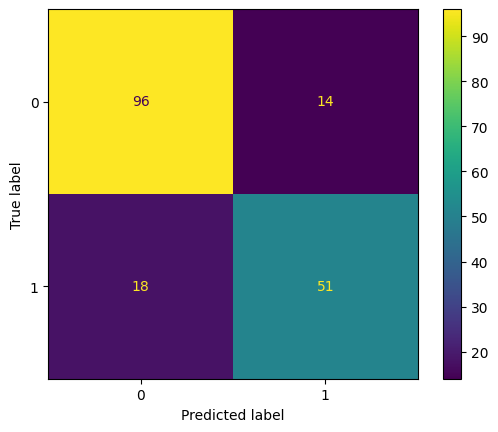

In [305]:
ConfusionMatrixDisplay.from_predictions(y_holdout, holdout_pred_outlier)

After cross-validating different outlier methods, `LocalOutlierFactor` proved to be the best. This is because in any group of people, anyone had a chance of surviving or not making it to the escape boat, despite class inequality. Those lucky or unlucky individuals impede our model from generalizing on the features, so it proved to be the best.

- Without outlier detection, our model had Holdout ROC-AUC of 0.8274 and f1-score of 0.83

- With `LocalOutlierFactor`, our model has Holdout ROC-AUC: 0.8521 and f1-score of 0.82

Higher ROC-AUC rate that our model can achieve a better TP rate while classifying less as FP.

#### Choosing Best Model

Now that we have established the features and the outlier detection method, we are ready to perform the final step of choosing the best model configuration for our dataset.

#### LogisticRegression

##### Training

In [300]:
lr_train_pipeline = Pipeline([
    ("preprocess", build_rf_preprocess_pipeline(X_train)),
    ("outlier", OutlierFeatureAppender(best_method_cls, outlier_method_params[best_outlier_method])),
    ("model", LogisticRegression(random_state=42))
])

lr_param_grid = {
    "model__penalty": ["elasticnet"],
    "model__solver": ["saga"],
    "model__C": [0.001, 0.01, 0.1, 1.0, 3.0, 10.0, 30.0, 100.0],
    "model__l1_ratio": [0.0, 0.2, 0.5, 0.8, 1.0],
    "model__class_weight": [None, "balanced"],
    "model__fit_intercept": [True, False],
    "model__tol": [1e-4, 1e-3],
    "model__max_iter": [3000],
}

X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

lr_scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
}

lr_grid = GridSearchCV(
    estimator=lr_train_pipeline,
    param_grid=lr_param_grid,
    cv=5,
    scoring=lr_scoring,
    refit="roc_auc",
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_dev, y_dev)

best_idx = lr_grid.best_index_
print("Best LogisticRegression params:", lr_grid.best_params_)
print("Best CV ROC-AUC:", lr_grid.cv_results_["mean_test_roc_auc"][best_idx])
print("CV F1-score (at best ROC-AUC params):", lr_grid.cv_results_["mean_test_f1"][best_idx])

Fitting 5 folds for each of 320 candidates, totalling 1600 fits


Fitting 5 folds for each of 320 candidates, totalling 1600 fits


Best LogisticRegression params: {'model__C': 1.0, 'model__class_weight': None, 'model__fit_intercept': True, 'model__l1_ratio': 0.0, 'model__max_iter': 3000, 'model__penalty': 'elasticnet', 'model__solver': 'saga', 'model__tol': 0.0001}
Best CV ROC-AUC: 0.8590742323971163
CV F1-score (at best ROC-AUC params): 0.7187349656358897


##### Classification Report

In [301]:
best_lr_model = lr_grid.best_estimator_
y_holdout_pred_lr = best_lr_model.predict(X_holdout)
y_holdout_proba_lr = best_lr_model.predict_proba(X_holdout)[:, 1]

print("Best LogisticRegression Holdout ROC-AUC:", roc_auc_score(y_holdout, y_holdout_proba_lr))
print(classification_report(y_holdout, y_holdout_pred_lr))

Best LogisticRegression Holdout ROC-AUC: 0.8504611330698287
              precision    recall  f1-score   support

           0       0.75      0.96      0.84       110
           1       0.89      0.48      0.62        69

    accuracy                           0.78       179
   macro avg       0.82      0.72      0.73       179
weighted avg       0.80      0.78      0.76       179



##### Confusion Matrix

As we can see from both the low recall score for Survived = 1 and from the confusion matrix, for about 48% of survivors the model predicted that the passenger did not survive. The accuracy for those who did not survive is quite high, though. 

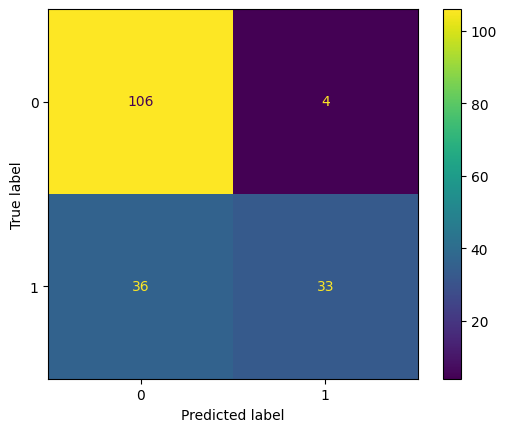

In [304]:
ConfusionMatrixDisplay.from_predictions(y_holdout, y_holdout_pred_lr)

#### Naive Bayes

##### Training

In [306]:
from sklearn.preprocessing import MinMaxScaler

nb_pipeline = Pipeline([
    ("preprocess", build_rf_preprocess_pipeline(X_train)),
    ("outlier", OutlierFeatureAppender(best_method_cls, outlier_method_params[best_outlier_method])),
    ("nb_scaler", "passthrough"),
    ("model", GaussianNB()),
])

nb_param_grid = [
    {
        "model": [GaussianNB()],
        "model__var_smoothing": [1e-12, 1e-10, 1e-9, 1e-8],
        "nb_scaler": ["passthrough"],
    },
    {
        "model": [MultinomialNB()],
        "model__alpha": [0.1, 0.5, 1.0, 2.0],
        "model__fit_prior": [True, False],
        "nb_scaler": [MinMaxScaler(feature_range=(0, 1))],
    },
    {
        "model": [BernoulliNB()],
        "model__alpha": [0.1, 0.5, 1.0, 2.0],
        "model__fit_prior": [True, False],
        "model__binarize": [0.0, 0.25, 0.5],
        "nb_scaler": [MinMaxScaler(feature_range=(0, 1))],
    },
]

nb_scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
}

nb_grid = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=nb_param_grid,
    cv=5,
    scoring=nb_scoring,
    refit="roc_auc",
    n_jobs=-1,
    verbose=1
)

nb_grid.fit(X_dev, y_dev)

best_nb_idx = nb_grid.best_index_
best_nb_model = nb_grid.best_estimator_
y_holdout_pred_nb = best_nb_model.predict(X_holdout)
y_holdout_proba_nb = best_nb_model.predict_proba(X_holdout)[:, 1]

print("Best Naive Bayes estimator:", type(best_nb_model.named_steps["model"]).__name__)
print("Best params:", nb_grid.best_params_)
print("Best CV ROC-AUC:", nb_grid.cv_results_["mean_test_roc_auc"][best_nb_idx])
print("CV F1-score (at best ROC-AUC params):", nb_grid.cv_results_["mean_test_f1"][best_nb_idx])
print("Holdout ROC-AUC:", roc_auc_score(y_holdout, y_holdout_proba_nb))
print(classification_report(y_holdout, y_holdout_pred_nb))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Naive Bayes estimator: BernoulliNB
Best params: {'model': BernoulliNB(), 'model__alpha': 0.5, 'model__binarize': 0.5, 'model__fit_prior': True, 'nb_scaler': MinMaxScaler()}
Best CV ROC-AUC: 0.8560010106287536
CV F1-score (at best ROC-AUC params): 0.7417961605923064
Holdout ROC-AUC: 0.8356389986824769
              precision    recall  f1-score   support

           0       0.88      0.66      0.76       110
           1       0.61      0.86      0.72        69

    accuracy                           0.74       179
   macro avg       0.75      0.76      0.74       179
weighted avg       0.78      0.74      0.74       179



##### Confusion Matrix

Naive Bayes was much more likely to attribute survival to those who have not. Very humane of it

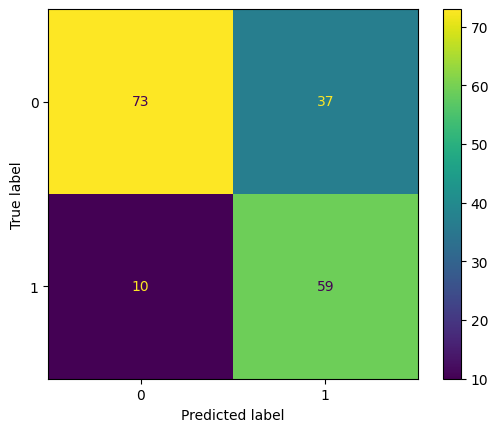

In [307]:
ConfusionMatrixDisplay.from_predictions(y_holdout, y_holdout_pred_nb)

#### SVC

##### Training

In [347]:
svc_pipeline = Pipeline([
    ("preprocess", build_rf_preprocess_pipeline(X_train)),
    ("outlier", OutlierFeatureAppender(best_method_cls, outlier_method_params[best_outlier_method])),
    ("model", SVC(probability=False, random_state=42, max_iter=3000)),
])

svc_param_grid = [
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1.0, 3.0, 10.0, 30.0],
        "model__gamma": ["scale", 0.1, 0.01, 0.001],
        "model__class_weight": [None, "balanced"],
    },
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1.0, 3.0, 10.0, 30.0],
        "model__class_weight": [None, "balanced"],
    },
]

svc_scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
}

svc_grid = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=svc_param_grid,
    cv=5,
    scoring=svc_scoring,
    refit="f1",
    n_jobs=-1,
    verbose=1
)

svc_grid.fit(X_dev, y_dev)

best_svc_idx = svc_grid.best_index_
best_svc_model = svc_grid.best_estimator_
y_holdout_pred_svc = best_svc_model.predict(X_holdout)

print("Best SVC params:", svc_grid.best_params_)
print("Best CV ROC-AUC:", svc_grid.cv_results_["mean_test_roc_auc"][best_svc_idx])
print("CV F1-score (at best ROC-AUC params):", svc_grid.cv_results_["mean_test_f1"][best_svc_idx])

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best SVC params: {'model__C': 30.0, 'model__class_weight': None, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
Best CV ROC-AUC: 0.8564177036825938
CV F1-score (at best ROC-AUC params): 0.765017945017945


##### Classification Report

The final f1 score for our RBF SVC is 0.82, the same as for RandomForestClassifier. The ROC-AUC score is also almost equivalent

In [348]:
print(classification_report(y_holdout, y_holdout_pred_svc))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



##### Confusion Matrix

Confusion Matrix is also basically the same as for RandomForestClassifier

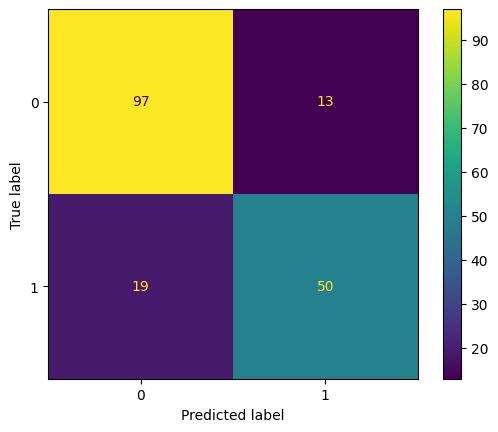

In [349]:
ConfusionMatrixDisplay.from_predictions(y_holdout, y_holdout_pred_svc)

### Conclusion

Engineered features allowed us to train a better model. RandomForestClassifier has shows it is the best with 0.82 f1 score. In HW, f1 score for LogisticRegression was 0.8 and this time for the same model it was 0.72, because there were more features with potentially less correlation. 